# Thí nghiệm 1: Ước lượng thông số Khách hàng (Estimation)

### 1. Mục tiêu
- So sánh 3 cách ước lượng độ không chắc chắn (Standard Error) của estimator:
    - Không dùng resampling (Naive / Công thức giải tích)
    - Jackknife
    - Bootstrap
- So sánh trực tiếp Jackknife vs Bootstrap bằng cách chỉ ra:
    - Trường hợp Jackknife và Bootstrap dùng tốt tương đương
    - Trường hợp Bootstrap tốt hơn hẳn Jackknife
- Chỉ số đánh giá: **Standard Error (SE)** và **Variance** của Estimator

### 2. Bối cảnh thực tế

Cũng như trong các bài toán marketing (như bank campaign), ta thường quan tâm:
- Tỷ lệ khách hàng đăng ký (tỉ lệ biến deposit có gia strij 'yes')
- Thu nhập trung bình (balance), hoặc các estimator phức tạp hơn (median, quantile)

Vấn đề:
- Dữ liệu không tuân theo phân phối chuẩn
- Không biết công thức SE chính xác

=> Phải dùng resampling methods (Jackknife / Bootstrap)

### 3. Câu hỏi đặt ra
- Jackknife và Bootstrap khác nhau thế nào về SE/Variance?
- Khi nào Bootstrap/Jackkinfe đáng tin hơn?
- Nếu không resampling thì sai lệch lớn cỡ nào?

### 4. Mô tả Dataset: Bank Marketing dataset
- **Nguồn**: UCI Machine Learning Repository.
- **Đặc điểm**: Dữ liệu bao gồm các thông tin như tuổi, nghề nghiệp, tình trạng hôn nhân, số dư tài khoản, và kết quả của các chiến dịch marketing trước đó.

| Cột | Ý nghĩa | Ghi chú |
|:---|:---|:---|
| **age** | Tuổi khách hàng | Biến định lượng |
| **job** | Nghề nghiệp | admin, blue-collar, technician, etc. |
| **marital** | Tình trạng hôn nhân | married, single, divorced |
| **education** | Học vấn | primary, secondary, tertiary, unknown |
| **balance** | Số dư tài khoản trung bình hàng năm | Đơn vị: Euro |
| **housing** | Có vay thế chấp nhà không? | yes/no |
| **loan** | Có vay cá nhân không? | yes/no |
| **contact** | Hình thức liên lạc | cellular, telephone |
| **duration** | Thời lượng cuộc gọi cuối cùng | Đơn vị: giây |
| **campaign** | Số lần liên lạc trong chiến dịch này | Bao gồm cả lần cuối |
| **pdays** | Số ngày trôi qua kể từ lần liên lạc trước | -1 nghĩa là chưa liên lạc |
| **deposit** | Khách hàng có đăng ký tiền gửi không? | **Biến mục tiêu (yes/no)** |

- **Tại sao chọn dataset này?**:
    - Dữ liệu có sự mất cân bằng nhẹ giữa các lớp (nhãn 'yes' và 'no').
    - Có sự kết hợp giữa biến định tính và định lượng, tạo ra sự phức tạp đủ để thấy sự khác biệt giữa các mô hình.
    - Phù hợp để minh họa việc kết quả Accuracy có thể bị nhiễu nếu chỉ dùng một lần split

In [1]:
# 1. Cài đặt công cụ tải
!npm install -g degit


# 2. Tải đúng 3 folder bạn yêu cầu
REPO = "Bubusr/MSA-Resampling-Methods"

print("🚀 Đang tải các thư mục cần thiết...")
!degit {REPO}/modules modules -f
!degit {REPO}/data data -f
!degit {REPO}/utils utils -f

# 3. Để Python nhận diện được code trong folder modules và utils
import sys
import os
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("\n✅ Tải hoàn tất! Cấu trúc hiện tại:")
!ls -F


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 1 package in 2s
⠋npm notice
npm notice New major version of npm available! 10.8.2 -> 11.13.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.13.0
npm notice To update run: npm install -g npm@11.13.0
npm notice
⠋🚀 Đang tải các thư mục cần thiết...
> cloned Bubusr/MSA-Resampling-Methods#HEAD to modules
> cloned Bubusr/MSA-Resampling-Methods#HEAD to data
> cloned Bubusr/MSA-Resampling-Methods#HEAD to utils

✅ Tải hoàn tất! Cấu trúc hiện tại:
data/  modules/  sample_data/  utils/


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 6. Quan sát ban đầu (EDA)

> Dataset Info:
  - Shape: 11162 observations × 17 features

  - First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

>  - Thống kê cột '

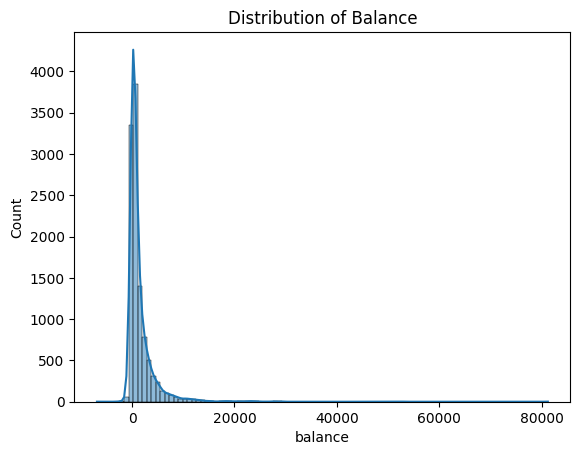

,proportion
deposit,
no,0.52616
yes,0.47384


In [4]:
# Tải và hiển thị thông tin dataset
df = pd.read_csv('data/bank.csv')

print("> Dataset Info:")
print(f"  - Shape: {df.shape[0]} observations × {df.shape[1]} features")
print(f"\n  - First 5 rows:")
print(df.head())

print(f"\n>  - Thống kê cột 'balance' (Target variable):")
print(df['balance'].describe())

print(f"\nDataset loaded successfully!")

# Vẽ biểu đồ phân phối của cột 'balance'
sns.histplot(df["balance"], bins=100, kde=True)
plt.title("Distribution of Balance")
plt.show()

# Tính tỷ lệ phần trăm của từng loại giá trị trong cột 'deposit'
df["deposit"].value_counts(normalize=True)

#### Nhận xét:

- **Hiện tượng trong biểu đồ**: Biểu đồ phân phối của `balance` có dạng đỉnh nhọn tập trung ở mức 0 và đuôi kéo dài rất xa về phía bên phải. Tỷ lệ phân lớp `deposit` có sự chênh lệch.
- **Tính chất data**: Biến `balance` bị lệch phải cực kỳ mạnh (highly right-skewed) và có chứa nhiều ngoại lai (outliers) có giá trị cực lớn.

### 7. Các hàm quan trọng

In [5]:
# 1. định nghĩa các estimator (means, medians, proportions)
def mean_estimator(data):
    return np.mean(data)

def median_estimator(data):
    return np.median(data)

def proportion_estimator(data):
    return np.mean(data == "yes")

# 2. ko resample, chỉ tính SE trực tiếp trên toàn bộ dataset
def naive_se(data, estimator):
    theta_hat = estimator(data)
    se = np.std(data, ddof=1) / np.sqrt(len(data))
    return theta_hat, se

# 3. Jackknife resampling
def jackknife(data, estimator):
    n = len(data)
    estimates = []

    for i in range(n):
        sample = np.delete(data, i)
        estimates.append(estimator(sample))

    estimates = np.array(estimates)
    theta_hat = estimator(data)

    se = np.sqrt((n - 1) / n * np.sum((estimates - theta_hat) ** 2))
    return theta_hat, se, estimates

# 4. Bootstrap resampling
def bootstrap(data, estimator, B=1000):
    n = len(data)
    estimates = []

    for _ in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        estimates.append(estimator(sample))

    estimates = np.array(estimates)

    theta_hat = np.mean(estimates)
    se = np.std(estimates)

    return theta_hat, se, estimates

### Phần 1: Khảo sát Estimator Trơn

**Thí nghiệm này sẽ làm gì?**

So sánh mức độ ước lượng Standard Error (SE) của Naive, Jackknife và Bootstrap khi dùng một estimator liên tục và trơn (smooth) như **Mean**. 

*(Lưu ý: Như đã phân tích ở phần EDA, tập dữ liệu `balance` bị lệch phải nghiêm trọng và chứa nhiều Outliers. Do đó, trong thực tế kinh doanh, ta bắt buộc phải dùng Trung vị (Median) để làm thước đo đại diện. Tuy nhiên, trong khuôn khổ thử nghiệm thuật toán Resampling, ta sẽ tạm mượn hàm toán học trơn tru kinh điển là Mean để làm "sandbox" thử nghiệm (baseline). Mục đích là để chứng minh rằng: Trong một môi trường tuyến tính và lý tưởng, cả 3 phương pháp tính SE đều sẽ hội tụ về cùng một kết quả tốt. Nắm vững baseline này rồi, ta mới dễ dàng thấy được sự sụp đổ của Jackknife khi bước vào bài toán phi tuyến (Median) ở Phần 2).*

In [6]:
data = df["balance"].values
    
naive_mean, naive_se_mean = naive_se(data, mean_estimator)
jk_mean, jk_se, jk_dist = jackknife(data, mean_estimator)
bs_mean, bs_se, bs_dist = bootstrap(data, mean_estimator)

Mean Estimation | Giá trị gốc: 1528.54
  - Naive SE (Giải tích): 30.53
  - Bootstrap SE: 30.92
  - Jackknife SE: 30.53


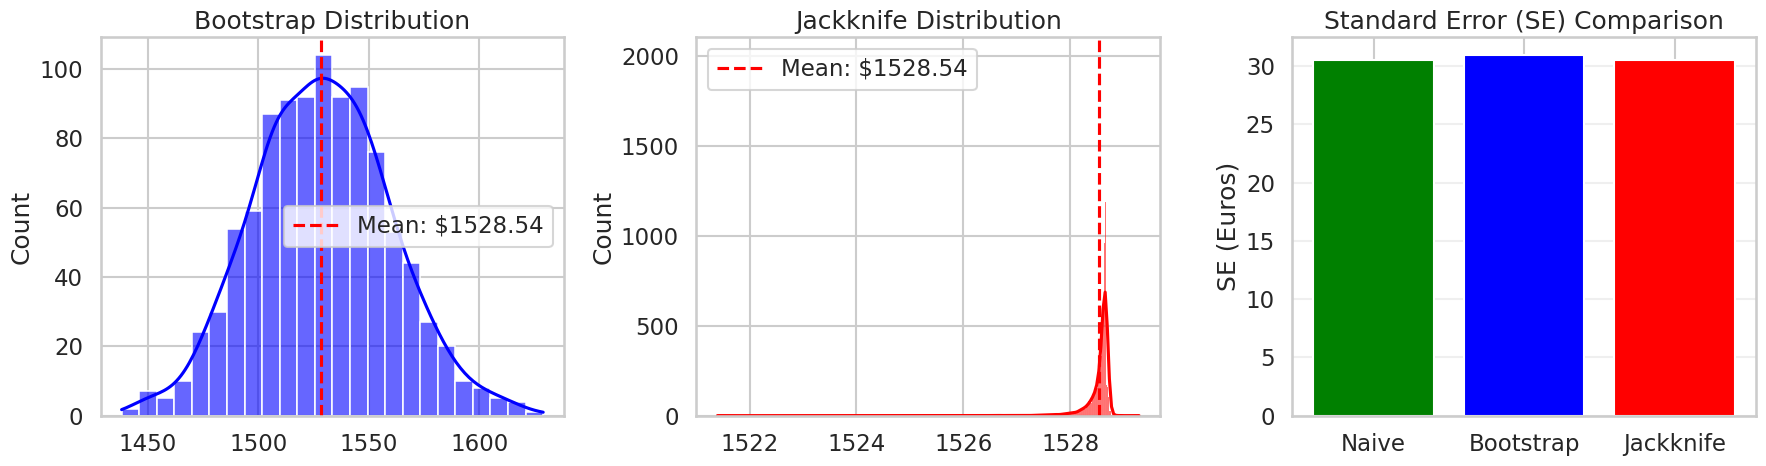

In [7]:
# In ra kết quả
print(f"Mean Estimation | Giá trị gốc: {np.mean(data):.2f}")
print(f"  - Naive SE (Giải tích): {naive_se_mean:.2f}")
print(f"  - Bootstrap SE: {bs_se:.2f}")
print(f"  - Jackknife SE: {jk_se:.2f}")

# Vẽ biểu đồ: 3 subplot (Phân phối Bootstrap, Phân phối Jackknife, So sánh SE)
sns.set_theme(style='whitegrid', context='talk')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bootstrap Distribution
sns.histplot(bs_dist, kde=True, ax=ax1, color='blue', alpha=0.6)
ax1.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: ${np.mean(data):.2f}')
ax1.set_title("Bootstrap Distribution")
ax1.legend()

# 2. Jackknife Distribution
sns.histplot(jk_dist, kde=True, ax=ax2, color='red', alpha=0.6)
ax2.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: ${np.mean(data):.2f}')
ax2.set_title("Jackknife Distribution")
ax2.legend()

# 3. SE Comparison
ax3.bar(['Naive', 'Bootstrap', 'Jackknife'], [naive_se_mean, bs_se, jk_se], color=['green', 'blue', 'red'])
ax3.set_title('Standard Error (SE) Comparison')
ax3.set_ylabel('SE (Euros)')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Nhận xét đánh giá (Mean Estimator):

**1. Về mặt Phân phối, Standard Error (SE) và Variance**
- **Hiệu năng của Naive SE**: Cách tính Naive bằng công thức giải tích cho kết quả SE hoàn toàn ngang bằng với Bootstrap và Jackknife. Điều này chứng minh rằng khi ta có sẵn công thức chuẩn (như $SE = \sigma/\sqrt{n}$ cho Mean), Resampling là không bắt buộc.
- **Hiện tượng Bootstrap vs Jackknife**: Phân phối Bootstrap có dạng hình chuông đều xung quanh Mean gốc. Trong khi đó, phân phối Jackknife rất hẹp và tập trung dày đặc. Đáng chú ý là mức chênh lệch về chiều cao Standard Error (SE) giữa Bootstrap và Jackknife (ở cột 3) là vô cùng nhỏ, gần như bằng nhau. Khác biệt về phương sai (Variance) của estimator cũng rất tiệm cận.
- **Tính chất data**: Mean là một estimator đại diện cho tính chất "trơn" (tuyến tính, smooth). Khi estimator có sự liên tục, việc thêm bớt đi một vài quan sát ở mức độ nhỏ giọt của Jackknife không làm mất đi tính đại diện phương sai của quần thể. 
- **Insight thực tế**: Đối với các estimator "trơn" và tuyến tính như Mean, cả 3 phương pháp (Naive, Bootstrap và Jackknife) đều hoạt động hiệu quả tương đương. Tuy nhiên, nếu bạn chỉ cần tìm khoảng tin cậy (CI) hoặc SE cho Mean, **việc tính Naive qua công thức giải tích là tối ưu nhất**, theo sau là Jackknife để tăng tốc độ tính toán mà không phải chạy mô phỏng đồ sộ như Bootstrap.

### Phần 2: Khảo sát Estimator Phi tuyến
**Mục tiêu**: Đánh giá sự breakdown của Jackknife khi đối mặt với các hàm gián đoạn như **Median** và chứng minh sự cần thiết của Bootstrap.

In [8]:
jk_med, jk_se_med, jk_dist_med = jackknife(data, median_estimator)
bs_med, bs_se_med, bs_dist_med = bootstrap(data, median_estimator)

Median Estimation | Giá trị gốc: 550.00 | Bootstrap SE: 11.89 | Jackknife SE: 0.00


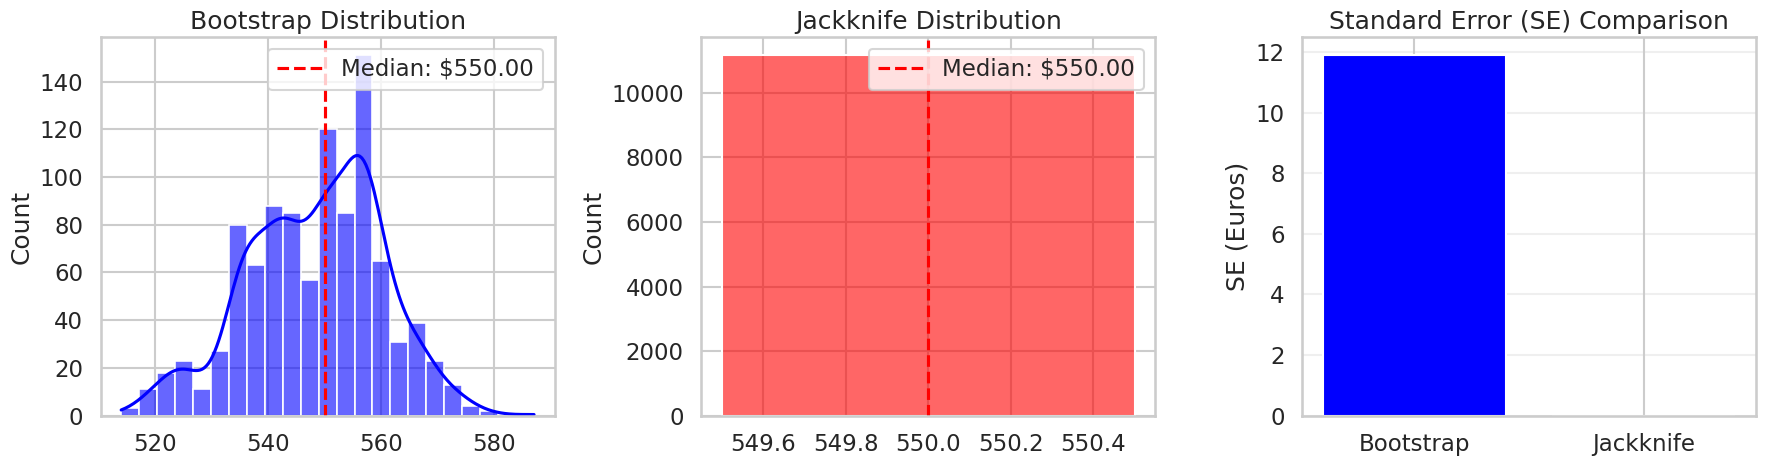

In [9]:
# In ra kết quả
print(f"Median Estimation | Giá trị gốc: {np.median(data):.2f} | Bootstrap SE: {bs_se_med:.2f} | Jackknife SE: {jk_se_med:.2f}")

# Vẽ biểu đồ: 3 subplot (Phân phối Bootstrap, Phân phối Jackknife, So sánh SE)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bootstrap Distribution
sns.histplot(bs_dist_med, kde=True, ax=ax1, color='blue', alpha=0.6)
ax1.axvline(np.median(data), color='red', linestyle='--', label=f'Median: ${np.median(data):.2f}')
ax1.set_title("Bootstrap Distribution")
ax1.legend()

# 2. Jackknife Distribution
sns.histplot(jk_dist_med, kde=True, ax=ax2, color='red', alpha=0.6)
ax2.axvline(np.median(data), color='red', linestyle='--', label=f'Median: ${np.median(data):.2f}')
ax2.set_title("Jackknife Distribution")
ax2.legend()

# 3. SE Comparison
ax3.bar(['Bootstrap', 'Jackknife'], [bs_se_med, jk_se_med], color=['blue', 'red'])
ax3.set_title('Standard Error (SE) Comparison')
ax3.set_ylabel('SE (Euros)')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

*Tổng số lần Jackknife thử nghiệm (Leave-one-out trên cỡ mẫu): 11162 lần
Nhưng số lượng kết quả biến thiên Median tạo ra chỉ có đúng: 1 giá trị!
Cụ thể là các giá trị: [550.]


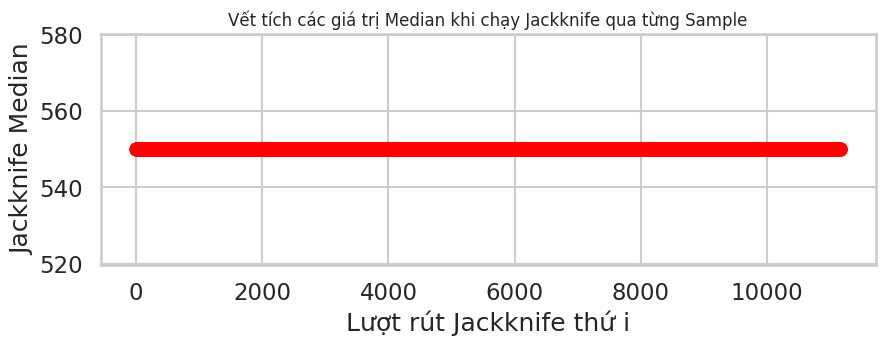

In [10]:
# Đoạn code nhỏ để chứng minh Jackknife không phản ánh đúng sự biến thiên của Median
unique_jk_med = np.unique(jk_dist_med)
print(f"*Tổng số lần Jackknife thử nghiệm (Leave-one-out trên cỡ mẫu): {len(jk_dist_med)} lần")
print(f"Nhưng số lượng kết quả biến thiên Median tạo ra chỉ có đúng: {len(unique_jk_med)} giá trị!")
print(f"Cụ thể là các giá trị: {unique_jk_med}")

# Vẽ một biểu đồ Line cực hạn để thấy nội tình của Jackknife
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(jk_dist_med, marker='o', linestyle='', alpha=0.5, color='red')
ax.set_title("Vết tích các giá trị Median khi chạy Jackknife qua từng Sample", fontsize=12)
ax.set_ylabel("Jackknife Median")
ax.set_xlabel("Lượt rút Jackknife thứ i")
plt.show()

#### Nhận xét đánh giá (Median Estimator):

**1. Tại giải thích hiện tượng Jackknife SE gần như bằng 0 (Hoặc cực thấp)**
- **Sự thật nhìn từ Line chart**: Như bạn thấy ở biểu đồ chấm (Vết tích Jackknife), trong suốt hơn 11,000 lần rút mẫu (leave-one-out), cái giá trị Median thu về gần như tạo thành **chỉ 1 đến 2 đường thẳng duy nhất**. Jackknife đã trả về hàng nghìn kết quả trùng lặp y xì đúc! Không có một chút biến thiên nào đáng kể.
- **Giải phẫu thuật toán**: Khi lấy Median (điểm đứng chính giữa của dữ liệu đã sort), nếu bạn xóa đi 1 quan sát ngẫu nhiên ở tít rìa (cỡ siêu nhỏ hoặc cực lớn), thì cái điểm chính giữa hầu như không xê dịch, hoặc xê dịch cực ít sang phần tử liền kề. Điều này khiến cho tập sample estimates $ \theta_{(i)} $ của Jackknife toàn là các con số rập khuôn.
- **Hệ lụy của việc rập khuôn**: Công thức tính Variance/SE dựa trên độ lệch $( \theta_{(i)} - \bar{\theta} )^2$. Do các $ \theta_{(i)} $ y hệt nhau nên độ lệch bằng 0 $\rightarrow$ Phương sai biến thành 0 $\rightarrow$ SE tụt thê thảm đầy phi lý.

**2. Kết luận**
- **Sự vắng mặt của Naive**: Đối với các dự tính phi tuyến (Non-smooth) như Median, ta không thể không resampling vì estimator median không có công thức giải tích sẵn có. 
- **Jackknife Break down**: Jackknife là một sự lừa dối với Median. Nó cung cấp một cái SE ảo (under-estimate trầm trọng) khiến người làm data lầm tưởng mô hình của mình là cực kỳ ổn định.
- **Sự hiệu quả của Bootstrap**: Bằng cách chọn ngẫu nhiên **có hoàn lại**, Bootstrap bóc ngẫu nhiên cả đống mẫu cùng lúc, thay đổi hoàn toàn cục diện phân vị ở giữa (có thể làm biến mất hoặc lặp lại nhiều lần các giá trị xung quanh trung tâm). Nó vẽ ra được một dải phân phối liên tục, rộng và trung thực. **Bắt buộc dùng Bootstrap** trong bài toán dính đến Median/Quantile.

### Tổng kết Lab 1

| Tham số / Phương pháp | Đặc điểm | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **Mặc định (Naive)** | Dùng công thức toán/giải tích | Cực nhanh và chính xác nếu đúng phân phối. | Vô dụng nếu không có công thức cho thống kê phức tạp (Median, Quantile, ...). |
| **Jackknife** | Rút trích kiểu Leave-one-out | Ước lượng được Variance rõ ràng, không chạy randomize mệt mỏi theo Seed. | **Hỏng nặng (Break down)** với estimator dời rạc cực tính (Như Median). |
| **Bootstrap** | Resample có ngẫu nhiên hoàn lại | Linh hoạt tính SE/Variance cho mọi loại estimator từ dễ tới hàm cực dị cứng. | Đo đạc tốn thời gian hơn. Cần nhiều quan sát gốc để chẩn đúng phân phối. |